In [1]:
%load_ext autoreload
%autoreload 2
import os
from substrata import *

/Users/pbongaerts/miniconda3/envs/substrata/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Overview
To execute all steps across all plots you can uncomment the `execute_all_steps` below (after a "Run all" to load in the different functions that define the steps). Alternatively, you can find all the individual steps (as functions) broken out below.

In [2]:
# Defining paths and plot ids
# Note that Annotations files need to have a header: id,x,y,z,label,species
annotations_path = '/Users/pbongaerts/Github/substrata/sandbox/mcav_sint/annotations/'
output_path = '/Users/pbongaerts/Github/substrata/sandbox/mcav_sint/output/'
plot_paths = {
    #'cur_sna_05m_20200303': '/Users/pbongaerts/Documents/Data/plots/cur_sna_05m_20200303/',
    #'cur_sna_10m_20200303': '/Users/pbongaerts/Documents/Data/plots/cur_sna_10m_20200303/',
    #'cur_sna_20m_20200303': '/Users/pbongaerts/Documents/Data/plots/cur_sna_20m_20200303/',
    #'cur_sna_40m_20200216': '/Users/pbongaerts/Documents/Data/plots/cur_sna_40m_20200216/',
    #'cur_sna_60m_20200216': '/Users/pbongaerts/Documents/Data/plots/cur_sna_60m_20200216/',
    #'cur_kal_05m_20200214': '/Users/pbongaerts/Documents/Data/plots/cur_kal_05m_20200214/',
    #'cur_kal_10m_20200214': '/Users/pbongaerts/Documents/Data/plots/cur_kal_10m_20200214/',
    'cur_kal_20m_20200214': '/Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/',
    #'cur_kal_40m_20200214': '/Users/pbongaerts/Documents/Data/plots/cur_kal_40m_20200214/',
    #'cur_kal_60m_20200214': '/Users/pbongaerts/Documents/Data/plots/cur_kal_60m_20200214/'
}

In [4]:
def execute_all_steps(): 
    for plot_id in plot_paths:
        plot_path = plot_paths[plot_id]
        plot_annotations_path = os.path.join(annotations_path, plot_id[0:11] + '_ann.csv')
        
        plot = load_plot_and_annotations(plot_path, plot_annotations_path)
        calc_distance_matrix(plot, output_path)
        calc_microhabitat_measurements(plot, output_path)

execute_all_steps()

Loading project from YAML file: /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214.yaml
Loading pointcloud from /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214_dec50M.ply
Loading cameras from /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214.meta.json and /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214.cams.xml
Loading markers from /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214_markers.csv
Loading annotations from /Users/pbongaerts/Github/substrata/sandbox/mcav_sint/annotations/cur_kal_20m_ann.csv
Applying world_transform to loaded objects:
[[-3.58525902e-03  1.77067686e-01 -5.69733344e-02  2.02176251e+01]
 [-1.42188338e-01 -3.93474389e-02 -1.13340355e-01  2.08304653e+00]
 [-1.19922487e-01  4.13593275e-02  1.36087411e-01 -2.02703304e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


NameError: name 'calc_distance_matrix' is not defined

## Load in the pointcloud and annotations and scale/orient using predefined saved world transform

Loading project from YAML file: /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214.yaml
Loading pointcloud from /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214_dec50M.ply
Loading cameras from /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214.meta.json and /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214.cams.xml
Loading markers from /Users/pbongaerts/Documents/Data/plots/cur_kal_20m_20200214/cur_kal_20m_20200214_markers.csv
Loading annotations from /Users/pbongaerts/Github/substrata/sandbox/mcav_sint/annotations/cur_kal_20m_ann.csv
Applying world_transform to loaded objects:
[[-3.58525902e-03  1.77067686e-01 -5.69733344e-02  2.02176251e+01]
 [-1.42188338e-01 -3.93474389e-02 -1.13340355e-01  2.08304653e+00]
 [-1.19922487e-01  4.13593275e-02  1.36087411e-01 -2.02703304e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


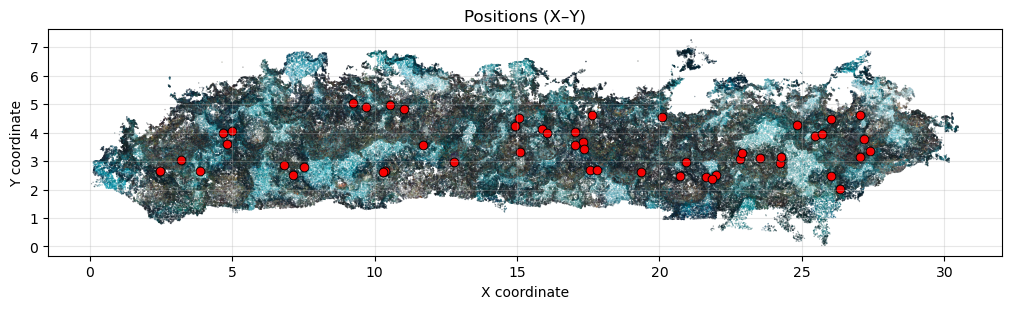

In [ ]:
def load_plot_and_annotations(plot_path, annotations_path):
    plot = ProjectInitializer(path = plot_path)
    plot.reset_paths_to_local(plot_path)        # not required when running on server
    plot.annotations_filepath = annotations_path
    plot.initialize()
    return plot

# Example execution
plot = load_plot_and_annotations(plot_paths['cur_kal_20m_20200214'],
                                 os.path.join(annotations_path, 'cur_kal_20m_ann.csv'))
# Visualize annotations
plot.annotations.show(plot.pcd, color=True)

In [4]:
from substrata.pointclouds import get_decimated_pcd
pcd_downsampled = get_decimated_pcd(plot.pcd, target_points=1_000_000)
pcd_downsampled.remove_edge_clusters(eps=0.5) 


: 

In [ ]:
# Visualize annotations
pcd_downsampled.annotations.show(plot.pcd, color=True)

## Calculate (within-plot) distances between each pair of samples

In [5]:
def calc_distance_matrix(plot, output_path):
    distance_matrix = plot.annotations.get_eucl_distance_matrix()
    distmat_output_filepath = os.path.join(output_path, f'{plot.id}_distmat.csv')
    distance_matrix.to_csv(distmat_output_filepath, index=True, index_label='')

# Example execution
calc_distance_matrix(plot, output_path)

## Calculate microhabitat measurements and save visualizations to PDF

In [6]:
def calc_microhabitat_measurements(plot, output_path, trial_run=False):
    if trial_run:
        annotations = plot.annotations.subset(5)
    else:
        annotations = plot.annotations
    measurements_output_filepath = os.path.join(output_path, f'{plot.id}_measurements.csv')
    # Sample point cloud around annotations with 0.2m radius
    annotations.get_point_cloud_by_radius(plot.pcd, 0.2)
    # Calculate microhabitat measurements
    annotations.measure_all(calc_gap_fraction, plot.pcd.simple_pcd)
    annotations.measure_all(calc_roughness)
    annotations.measure_all(get_plane_angles)
    # Save microhabitat measurements
    annotations.save(measurements_output_filepath)
    visualizations.save_measurement_visualizations_to_pdf(annotations, f'{plot.id}_measurements.pdf')

# Example execution
calc_microhabitat_measurements(plot, output_path, trial_run=True)

Subsampling pointcloud for each annotation: 100%|██████████| 5/5 [00:33<00:00,  6.75s/it]
Conducting <function calc_gap_fraction at 0x340dd4af0> measurement for all annotations...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Conducting <function get_plane_angles at 0x340dd4280> measurement for all annotations...:   0%|          | 0/5 [00:15<?, ?it/s]

PDF created: cur_kal_20m_20200214_measurements.pdf


## Evaluate individual microhabitat measurements

Conducting <function calc_gap_fraction at 0x340dd4af0> measurement for all annotations...:   0%|          | 0/5 [01:13<?, ?it/s]
Conducting <function calc_roughness at 0x340dd4430> measurement for all annotations...:   0%|          | 0/5 [00:28<?, ?it/s]


MCCPKA20G0292_green MCAV_green [ -3.5378919 -80.894562   19.1280079]


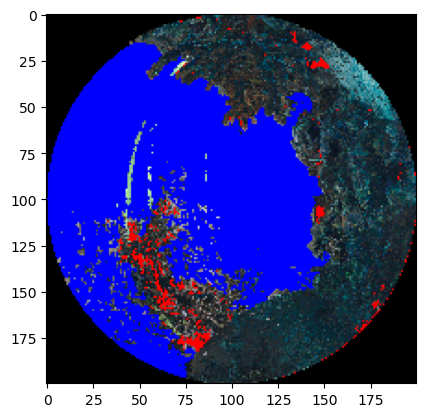

In [ ]:
def visualize_microhabitat_measurements(ann):

        print(ann.id, ann.label, ann.orig_coords)
        # Elevation angle
        visualizations.visualize_elevation_angle(ann.simple_pcd, 
                                                 ann.measurements["plane_coeffs"], 
                                                 interactive=True)
        # Roughness
        visualizations.visualize_roughness(ann.simple_pcd, 
                                           ra=ann.measurements["Ra"], 
                                           rq=ann.measurements["Rq"], 
                                           interactive=True)
        # Gap fraction
        plt.imshow(ann.measurements["gapF_image"])
        plt.show()
            
# Example execution
visualize_microhabitat_measurements(plot.annotations["MCCPKA20G0292_green"])